## Install Packages

In [1]:
import sys, site, platform
print("Python:", sys.version)
print("Executable:", sys.executable)
print("Platform:", platform.platform())
print("Site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")


Python: 3.12.3 (main, Nov  6 2025, 13:44:16) [GCC 13.3.0]
Executable: /home/ubuntu/venv/bin/python
Platform: Linux-6.14.0-1018-aws-x86_64-with-glibc2.39
Site-packages: ['/home/ubuntu/venv/lib/python3.12/site-packages', '/home/ubuntu/venv/local/lib/python3.12/dist-packages', '/home/ubuntu/venv/lib/python3/dist-packages', '/home/ubuntu/venv/lib/python3.12/dist-packages']


In [2]:
!python -V
!pip show torch transformers pyarrow

Python 3.12.3


Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /home/ubuntu/venv/lib/python3.12/site-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: torchaudio, torchvision
---
Name: transformers
Version: 4.57.3
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/co

In [3]:
!pip install pandas matplotlib tqdm pyarrow transformers gdown ujson

In [4]:
!python -m pip install -U pip setuptools wheel
!pip --version


pip 25.3 from /home/ubuntu/venv/lib/python3.12/site-packages/pip (python 3.12)


In [5]:
!nvidia-smi


Sun Jan  4 03:57:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:31:00.0 Off |                    0 |
| N/A   41C    P0             29W /   72W |       0MiB /  23034MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124


Looking in indexes: https://download.pytorch.org/whl/cu124


In [8]:
!pip install pandas matplotlib tqdm transformers gdown ujson

In [9]:
!pip install pyarrow

In [11]:
import torch
import os, json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


torch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA L4


In [3]:
import os, json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## Load TWeddit

In [12]:
DATA_PATH = "../datasets/5000_Posts_Annotations - Combined_Dataset.csv"  # <-- change me

df = pd.read_csv(DATA_PATH)
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head(2)

Rows: 4994
Columns: ['id', 'subreddit', 'title', 'body', 'Tags', 'Unnamed: 5']


,id,subreddit,title,body,Tags,Unnamed: 5
0,1ljxynj,abortion,Complications after abortion?,"Hi everyone, Ive read that abortions don’t cau...","Medical, Pregnancy, Mental Health",NaN
1,1ljxtt8,abortion,Second MA abortion today and I'm absolutely te...,I'm having my second MA abortion today and I'm...,"Medical, Pregnancy, Mental Health",NaN


In [13]:
TITLE_COL = "title"
BODY_COL  = "body"

def build_text(row):
    t = str(row.get(TITLE_COL, "")).strip()
    b = str(row.get(BODY_COL, "")).strip()
    if t and b:
        return f"{t}\n\n{b}"
    return t or b

df["text"] = df.apply(build_text, axis=1)

# Create an ID column if you don't have one
ID_COL = "post_id" if "post_id" in df.columns else None
if ID_COL is None:
    df["post_id"] = np.arange(len(df))
    ID_COL = "post_id"

df[[ID_COL, "text"]].head(3)


,post_id,text
0,0,"Complications after abortion?\n\nHi everyone, ..."
1,1,Second MA abortion today and I'm absolutely te...
2,2,Help needed/ live in Texas where abortion in b...


In [14]:
# If you already have created_utc:
if "created_utc" in df.columns:
    df["created_dt"] = pd.to_datetime(df["created_utc"], unit="s", utc=True).dt.tz_convert(None)
elif "created_dt" in df.columns:
    df["created_dt"] = pd.to_datetime(df["created_dt"])
else:
    df["created_dt"] = pd.NaT  # timeline plots will be skipped unless you fill this


## DAMF

In [13]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using DEVICE:", DEVICE)


Using DEVICE: cuda


In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MF_MODEL_NAME = "MMADS/MoralFoundationsClassifier"  # :contentReference[oaicite:2]{index=2}
mf_tokenizer = AutoTokenizer.from_pretrained(MF_MODEL_NAME)
mf_model = AutoModelForSequenceClassification.from_pretrained(MF_MODEL_NAME).to(DEVICE)
mf_model.eval()

# Label names (virtue/vice pairs) per model card :contentReference[oaicite:3]{index=3}
mf_src_labels = [
    "care_virtue",
    "care_vice",
    "fairness_virtue",
    "fairness_vice",
    "loyalty_virtue",
    "loyalty_vice",
    "authority_virtue",
    "authority_vice",
    "sanctity_virtue",
    "sanctity_vice",
]

# Map to DAMF-style 10 labels
mf_to_damf = {
    "care_virtue": "care",
    "care_vice": "harm",
    "fairness_virtue": "fairness",
    "fairness_vice": "cheating",
    "loyalty_virtue": "loyalty",
    "loyalty_vice": "betrayal",
    "authority_virtue": "authority",
    "authority_vice": "subversion",
    "sanctity_virtue": "purity",
    "sanctity_vice": "degradation",
}
damf_labels = list(mf_to_damf.values())
damf_labels


['care',
 'harm',
 'fairness',
 'cheating',
 'loyalty',
 'betrayal',
 'authority',
 'subversion',
 'purity',
 'degradation']

In [15]:
@torch.no_grad()
def mf_predict_proba(texts, batch_size=16, max_length=256):
    probs_all = []
    for i in tqdm(range(0, len(texts), batch_size), desc="MF batches"):
        batch = texts[i:i+batch_size]
        enc = mf_tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(DEVICE)

        logits = mf_model(**enc).logits
        probs = torch.sigmoid(logits).cpu().numpy()  # (bs, 10)
        probs_all.append(probs)

    return np.vstack(probs_all)

mf_probs = mf_predict_proba(df["text"].tolist(), batch_size=16, max_length=256)
mf_probs.shape


MF batches: 100%|██████████| 313/313 [00:29<00:00, 10.52it/s]


(4994, 10)

In [16]:
# Add source columns
for j, lab in enumerate(mf_src_labels):
    df[f"mf_{lab}_p"] = mf_probs[:, j]

# Convert to DAMF-style 10 columns
for src_lab, damf_lab in mf_to_damf.items():
    df[f"damf_{damf_lab}_p"] = df[f"mf_{src_lab}_p"]

# Threshold (tune this!)
MF_THRESHOLD = 0.50
for damf_lab in damf_labels:
    df[f"damf_{damf_lab}"] = (df[f"damf_{damf_lab}_p"] >= MF_THRESHOLD).astype(int)

df[[ID_COL] + [f"damf_{x}_p" for x in damf_labels]].head(3)


,post_id,damf_care_p,damf_harm_p,damf_fairness_p,damf_cheating_p,damf_loyalty_p,damf_betrayal_p,damf_authority_p,damf_subversion_p,damf_purity_p,damf_degradation_p
0,0,0.003438,0.966401,0.001048,0.002625,0.002817,0.002294,0.008466,0.001026,0.003422,0.005915
1,1,0.002046,0.938751,0.001945,0.006581,0.002041,0.006259,0.010394,0.015026,0.002759,0.007386
2,2,0.988506,0.003383,0.001098,0.000688,0.002149,0.000553,0.004982,0.000816,0.002226,0.001553


In [17]:
if df["created_dt"].notna().any():
    tmp = df.dropna(subset=["created_dt"]).copy()
    tmp["date"] = tmp["created_dt"].dt.date

    series = tmp.groupby("date")[[f"damf_{x}_p" for x in damf_labels]].mean()

    plt.figure()
    for col in series.columns:
        plt.plot(series.index, series[col], label=col.replace("damf_", "").replace("_p",""))
    plt.xticks(rotation=45)
    plt.title("Moral Foundations over time (mean probability)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No created_dt available — skipping timeline plot.")


No created_dt available — skipping timeline plot.


In [18]:
MF_THRESHOLD = 0.50  # try 0.30 / 0.40 / 0.50 and see what feels right

damf_labels = [
    "care","harm","fairness","cheating","loyalty",
    "betrayal","authority","subversion","purity","degradation"
]

for lab in damf_labels:
    pcol = f"damf_{lab}_p"
    outcol = f"damf_{lab}"
    df[outcol] = (df[pcol] >= MF_THRESHOLD).astype(int)

# quick peek
show_cols = ["post_id"] + [f"damf_{x}_p" for x in damf_labels] + [f"damf_{x}" for x in damf_labels]
df[show_cols].head(3)

,post_id,damf_care_p,damf_harm_p,damf_fairness_p,damf_cheating_p,damf_loyalty_p,damf_betrayal_p,damf_authority_p,damf_subversion_p,damf_purity_p,...,damf_care,damf_harm,damf_fairness,damf_cheating,damf_loyalty,damf_betrayal,damf_authority,damf_subversion,damf_purity,damf_degradation
0,0,0.003438,0.966401,0.001048,0.002625,0.002817,0.002294,0.008466,0.001026,0.003422,...,0,1,0,0,0,0,0,0,0,0
1,1,0.002046,0.938751,0.001945,0.006581,0.002041,0.006259,0.010394,0.015026,0.002759,...,0,1,0,0,0,0,0,0,0,0
2,2,0.988506,0.003383,0.001098,0.000688,0.002149,0.000553,0.004982,0.000816,0.002226,...,1,0,0,0,0,0,0,0,0,0


In [19]:
pcols = [f"damf_{x}_p" for x in damf_labels]

df["damf_top_label"] = df[pcols].idxmax(axis=1).str.replace("damf_", "", regex=False).str.replace("_p", "", regex=False)
df["damf_top_p"] = df[pcols].max(axis=1)

df[["post_id", "damf_top_label", "damf_top_p"]].head(10)

,post_id,damf_top_label,damf_top_p
0,0,harm,0.966401
1,1,harm,0.938751
2,2,care,0.988506
3,3,purity,0.989918
4,4,care,0.954838
5,5,care,0.912512
6,6,care,0.944189
7,7,harm,0.987779
8,8,authority,0.991221
9,9,care,0.945758


In [20]:
top_dist = df["damf_top_label"].value_counts(dropna=False).to_frame("count")
top_dist["percent"] = (top_dist["count"] / len(df) * 100).round(2)
top_dist


,count,percent
damf_top_label,,
care,1663,33.30
harm,1215,24.33
authority,687,13.76
loyalty,659,13.20
purity,338,6.77
degradation,294,5.89
fairness,93,1.86
cheating,35,0.70
subversion,9,0.18


In [23]:
damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
mean_probs = df[[f"damf_{x}_p" for x in damf_labels]].mean().sort_values(ascending=False)
mean_probs


damf_care_p           0.508902
damf_harm_p           0.393973
damf_loyalty_p        0.247445
damf_degradation_p    0.244180
damf_purity_p         0.188721
damf_authority_p      0.170709
damf_fairness_p       0.079946
damf_cheating_p       0.045310
damf_subversion_p     0.016149
damf_betrayal_p       0.009547
dtype: float32

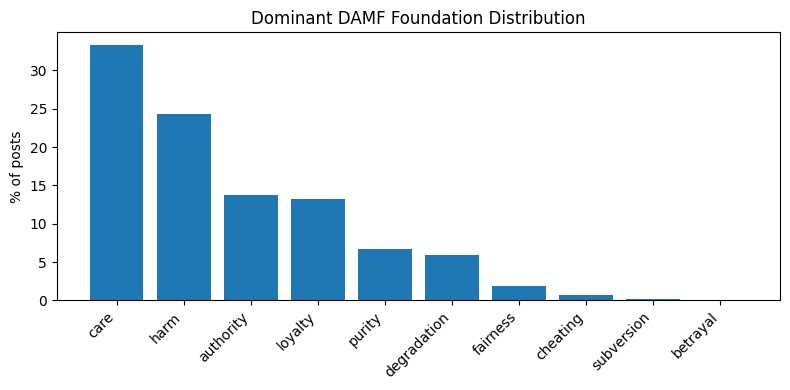

In [25]:
import matplotlib.pyplot as plt

td = (
    top_dist
    .reset_index()
    .rename(columns={"index": "damf_top_label"})
    .sort_values("count", ascending=False)
)

plt.figure(figsize=(8,4))
plt.bar(td["damf_top_label"], td["percent"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("% of posts")
plt.title("Dominant DAMF Foundation Distribution")
plt.tight_layout()
plt.show()


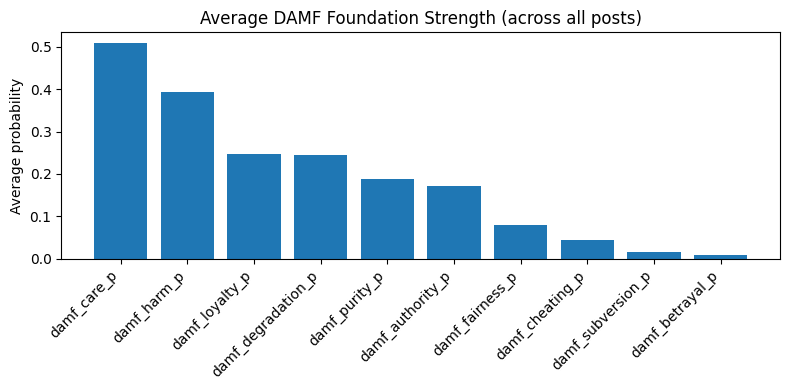

In [26]:
import matplotlib.pyplot as plt

mp = mean_probs.sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(mp.index, mp.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average probability")
plt.title("Average DAMF Foundation Strength (across all posts)")
plt.tight_layout()
plt.show()


In [27]:
bin_cols = [f"damf_{x}" for x in damf_labels if f"damf_{x}" in df.columns]
if bin_cols:
    (df[bin_cols].mean().sort_values(ascending=False) * 100).round(2)
else:
    print("No binary columns found. Run the thresholding cell first.")


In [28]:
[c for c in df.columns if "utc" in c.lower() or "date" in c.lower() or "time" in c.lower() or "created" in c.lower()]

['created_dt']

In [29]:
import json
import pandas as pd

ID_COL = "id"          # you have "id", not "post_id"
TAGS_COL = "Tags"      # your tags are here

TW_LABELS = ["Medical","Mental Health","Abuse","Aggression","Sexual","Discrimination","Pregnancy","Not Applicable"]

def parse_tags(x):
    """
    Robust parsing for Tags column.
    Handles:
      - JSON-like lists: ["Medical","Abuse"]
      - Python-like lists as strings: ['Medical', 'Abuse']
      - separators: ; , |
      - single label string
      - empty/NaN
    """
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(t).strip() for t in x if str(t).strip()]

    s = str(x).strip()
    if not s:
        return []

    # JSON-ish list
    if s.startswith("[") and s.endswith("]"):
        try:
            arr = json.loads(s.replace("'", '"'))
            if isinstance(arr, list):
                return [str(t).strip() for t in arr if str(t).strip()]
        except Exception:
            pass

    # split by common separators
    for sep in [";", "|", ","]:
        if sep in s:
            return [t.strip() for t in s.split(sep) if t.strip()]

    return [s]

parsed = df[TAGS_COL].apply(parse_tags)

for lab in TW_LABELS:
    df[lab] = parsed.apply(lambda lst: int(lab in lst))

# quick check: how many posts per label
df[TW_LABELS].sum().sort_values(ascending=False)


Mental Health     3550
Pregnancy         2652
Medical           1815
Abuse             1703
Sexual             918
Not Applicable     862
Discrimination     526
Aggression         196
dtype: int64

In [31]:
damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
damf_pcols = [f"damf_{x}_p" for x in damf_labels]

tw_present = [c for c in TW_LABELS if c in df.columns]
print("TW labels found:", tw_present)

rows = []
for lab in tw_present:
    sub = df[df[lab] == 1]
    if len(sub) == 0:
        continue
    row = {"tw_label": lab, "n": len(sub)}
    row.update(sub[damf_pcols].mean().to_dict())
    rows.append(row)

if not rows:
    print("No TW rows found (either Tags empty or labels not matching).")
else:
    tw_moral = pd.DataFrame(rows).sort_values("n", ascending=False)
    display(tw_moral)


TW labels found: ['Medical', 'Mental Health', 'Abuse', 'Aggression', 'Sexual', 'Discrimination', 'Pregnancy', 'Not Applicable']


,tw_label,n,damf_care_p,damf_harm_p,damf_fairness_p,damf_cheating_p,damf_loyalty_p,damf_betrayal_p,damf_authority_p,damf_subversion_p,damf_purity_p,damf_degradation_p
1,Mental Health,3550,0.519977,0.433386,0.078629,0.041701,0.244758,0.008927,0.166078,0.013912,0.189742,0.262438
6,Pregnancy,2652,0.529277,0.270035,0.061415,0.030773,0.203995,0.007085,0.139380,0.014520,0.249452,0.110133
0,Medical,1815,0.479672,0.275630,0.041363,0.023557,0.145429,0.006198,0.116846,0.014301,0.281709,0.107614
2,Abuse,1703,0.493780,0.642513,0.102571,0.060852,0.303743,0.012348,0.227194,0.015407,0.104930,0.465759
4,Sexual,918,0.473682,0.591145,0.080210,0.045435,0.266367,0.009278,0.194762,0.013115,0.110064,0.442628
7,Not Applicable,862,0.535679,0.296316,0.106799,0.078483,0.335187,0.014344,0.210246,0.026567,0.189105,0.217078
5,Discrimination,526,0.618736,0.496586,0.155526,0.057241,0.329699,0.013480,0.298929,0.023343,0.183261,0.360441
3,Aggression,196,0.530235,0.698316,0.101225,0.079597,0.321115,0.013482,0.307395,0.016458,0.132826,0.402455


In [32]:
damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
pcols = [f"damf_{x}_p" for x in damf_labels]

tw_moral2 = tw_moral.copy()

def topk_row(row, k=3):
    vals = row[pcols].sort_values(ascending=False).head(k)
    return ", ".join([f"{c.replace('damf_','').replace('_p','')}={v:.3f}" for c, v in vals.items()])

tw_moral2["top3_moral"] = tw_moral2.apply(topk_row, axis=1)
tw_moral2[["tw_label","n","top3_moral"]]


,tw_label,n,top3_moral
1,Mental Health,3550,"care=0.520, harm=0.433, degradation=0.262"
6,Pregnancy,2652,"care=0.529, harm=0.270, purity=0.249"
0,Medical,1815,"care=0.480, purity=0.282, harm=0.276"
2,Abuse,1703,"harm=0.643, care=0.494, degradation=0.466"
4,Sexual,918,"harm=0.591, care=0.474, degradation=0.443"
7,Not Applicable,862,"care=0.536, loyalty=0.335, harm=0.296"
5,Discrimination,526,"care=0.619, harm=0.497, degradation=0.360"
3,Aggression,196,"harm=0.698, care=0.530, degradation=0.402"


In [33]:
baseline_label = "Not Applicable"
base = tw_moral[tw_moral["tw_label"] == baseline_label].iloc[0]

delta_rows = []
for _, row in tw_moral.iterrows():
    lab = row["tw_label"]
    if lab == baseline_label:
        continue
    d = {"tw_label": lab, "n": int(row["n"])}
    for c in pcols:
        d[c.replace("_p","_delta_vs_NA")] = row[c] - base[c]
    delta_rows.append(d)

tw_delta = pd.DataFrame(delta_rows)

# show biggest positive deltas in harm & degradation (often interesting for TW)
tw_delta[["tw_label","n","damf_harm_delta_vs_NA","damf_degradation_delta_vs_NA","damf_care_delta_vs_NA"]].sort_values(
    "damf_harm_delta_vs_NA", ascending=False
)


,tw_label,n,damf_harm_delta_vs_NA,damf_degradation_delta_vs_NA,damf_care_delta_vs_NA
6,Aggression,196,0.402000,0.185377,-0.005443
3,Abuse,1703,0.346198,0.248681,-0.041899
4,Sexual,918,0.294829,0.225550,-0.061997
5,Discrimination,526,0.200271,0.143363,0.083057
0,Mental Health,3550,0.137071,0.045360,-0.015702
2,Medical,1815,-0.020686,-0.109464,-0.056007
1,Pregnancy,2652,-0.026280,-0.106945,-0.006401


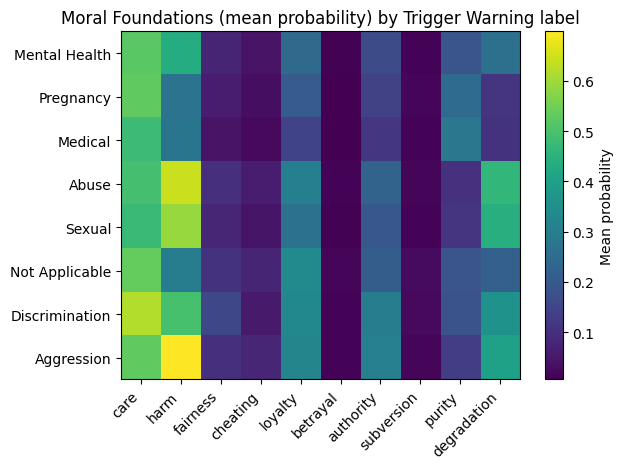

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Order labels by n (already sorted in your screenshot, but ensure)
plot_df = tw_moral.sort_values("n", ascending=False).copy()

M = plot_df[pcols].to_numpy()
labels_y = plot_df["tw_label"].tolist()
labels_x = [c.replace("damf_","").replace("_p","") for c in pcols]

plt.figure()
plt.imshow(M, aspect="auto")
plt.xticks(range(len(labels_x)), labels_x, rotation=45, ha="right")
plt.yticks(range(len(labels_y)), labels_y)
plt.colorbar(label="Mean probability")
plt.title("Moral Foundations (mean probability) by Trigger Warning label")
plt.tight_layout()
plt.show()


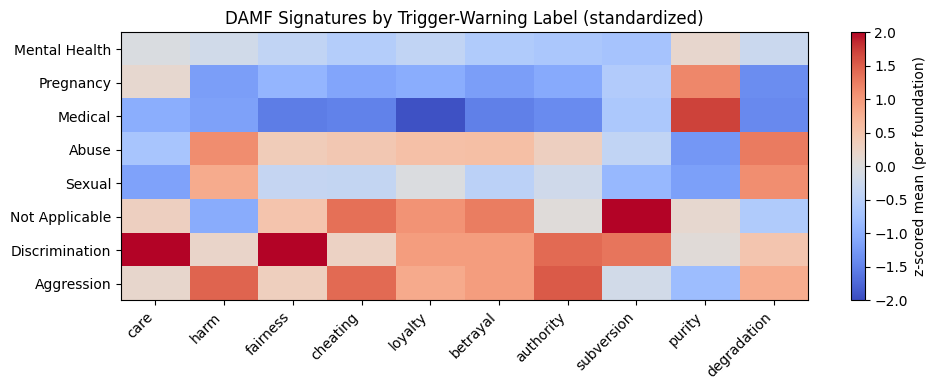

In [42]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = tw_moral.sort_values("n", ascending=False).copy()
M = plot_df[pcols].to_numpy()

# z-score by column (foundation)
M_z = (M - M.mean(axis=0, keepdims=True)) / (M.std(axis=0, keepdims=True) + 1e-9)

labels_y = plot_df["tw_label"].tolist()
labels_x = [c.replace("damf_","").replace("_p","") for c in pcols]

plt.figure(figsize=(10,4))
im = plt.imshow(M_z, aspect="auto", vmin=-2, vmax=2, cmap="coolwarm")  # centered at 0
plt.xticks(range(len(labels_x)), labels_x, rotation=45, ha="right")
plt.yticks(range(len(labels_y)), labels_y)

plt.colorbar(im, label="z-scored mean (per foundation)")
plt.title("DAMF Signatures by Trigger-Warning Label (standardized)")
plt.tight_layout()
plt.show()


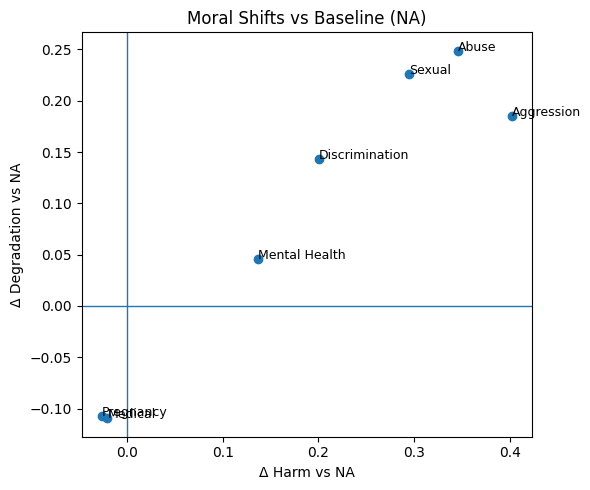

In [37]:
plt.figure(figsize=(6,5))
plt.scatter(tw_delta["damf_harm_delta_vs_NA"], tw_delta["damf_degradation_delta_vs_NA"])

for _, r in tw_delta.iterrows():
    plt.text(r["damf_harm_delta_vs_NA"], r["damf_degradation_delta_vs_NA"], r["tw_label"], fontsize=9)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Δ Harm vs NA")
plt.ylabel("Δ Degradation vs NA")
plt.title("Moral Shifts vs Baseline (NA)")
plt.tight_layout()
plt.show()


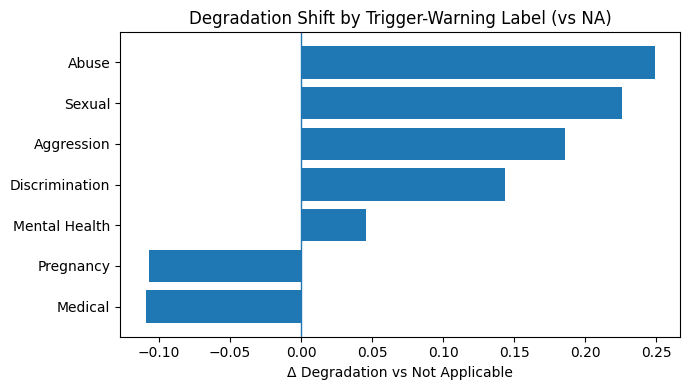

In [38]:
d = tw_delta.sort_values("damf_degradation_delta_vs_NA", ascending=True)

plt.figure(figsize=(7,4))
plt.barh(d["tw_label"], d["damf_degradation_delta_vs_NA"])
plt.axvline(0, linewidth=1)
plt.xlabel("Δ Degradation vs Not Applicable")
plt.title("Degradation Shift by Trigger-Warning Label (vs NA)")
plt.tight_layout()
plt.show()


## Emotion Analysis

In [77]:
import os, sys, json
import pandas as pd
import numpy as np

# Assumes df already exists and has a "text" column and ID_COL from earlier cells.
print("ID_COL:", ID_COL)
print("Has text?", "text" in df.columns, "Rows:", len(df))

# Your semeval extraction folder from earlier
OUT_DIR = "semeval_pretrained"
PRETRAINED_FOLDER = os.path.join(OUT_DIR, "semeval")  # <- IMPORTANT

print("PRETRAINED_FOLDER:", PRETRAINED_FOLDER)
print("Exists?", os.path.exists(PRETRAINED_FOLDER))
if os.path.exists(PRETRAINED_FOLDER):
    print("Files:", os.listdir(PRETRAINED_FOLDER))


ID_COL: id
Has text? True Rows: 4994
PRETRAINED_FOLDER: semeval_pretrained/semeval
Exists? True
Files: ['config.json', 'model.pt', 'README.md']


In [78]:
import pathlib, re

trainer_path = pathlib.Path("Demux-MEmo/emorec/trainer.py")
txt = trainer_path.read_text(encoding="utf-8")

txt2 = re.sub(
    r"from transformers\.optimization import get_linear_schedule_with_warmup, AdamW",
    "from transformers.optimization import get_linear_schedule_with_warmup\nfrom torch.optim import AdamW",
    txt
)

if txt == txt2:
    print("Patch pattern not found. Showing first 50 lines so we can patch manually if needed:")
    print("\n".join(txt.splitlines()[:50]))
else:
    trainer_path.write_text(txt2, encoding="utf-8")
    print("✅ Patched:", trainer_path)


Patch pattern not found. Showing first 50 lines so we can patch manually if needed:
import logging
from typing import Optional, Union, Dict, List, Iterable, Any, Tuple
from abc import ABC, abstractmethod

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_recall_fscore_support
from tqdm import tqdm
from transformers.optimization import get_linear_schedule_with_warmup
from torch.optim import AdamW

from emorec.utils import flatten_list
from emorec.train_utils import EarlyStopping
from emorec.logging_utils import ExperimentHandler


def result_str(results: Dict[str, float]):
    return ", ".join(
        [
            f"{key}={value:.4f}"
            if isinstance(value, float)
            else f"{key}={value}"
            for key, value in results.items()
        ]
    )


class BaseTrainer(ABC):
    """Trainer class for Twitter-201{5, 7} TMSC.

    Attributes:
        model: the model to train.
  

In [79]:
import numpy as np
import pandas as pd

# 1) create a stable id for every row
df = df.reset_index(drop=True).copy()
df["row_uid"] = np.arange(len(df)).astype(int)

# 2) write emotion input using row_uid
EMO_IN = "emo_input_allrows.csv"

emo_in_df = df[["row_uid", "text"]].copy()
emo_in_df["text"] = emo_in_df["text"].fillna("").astype(str)

emo_in_df.to_csv(EMO_IN, index=False)

print("Wrote:", EMO_IN, "Rows:", len(emo_in_df))
emo_in_df.head(2)


Wrote: emo_input_allrows.csv Rows: 4994


,row_uid,text
0,0,"Complications after abortion?\n\nHi everyone, ..."
1,1,Second MA abortion today and I'm absolutely te...


In [80]:
import glob
cfgs = glob.glob("Demux-MEmo/emotion_configs/*.json")
print("Configs:", cfgs)

EMO_CFG = None
for c in cfgs:
    if "semeval" in c.lower():
        EMO_CFG = c
        break

print("Using EMO_CFG:", EMO_CFG)
assert EMO_CFG is not None, "Could not find SemEval config."


Configs: ['Demux-MEmo/emotion_configs/goemotions.json', 'Demux-MEmo/emotion_configs/paletz_revised.json', 'Demux-MEmo/emotion_configs/paletz.json', 'Demux-MEmo/emotion_configs/semeval2018task1.json']
Using EMO_CFG: Demux-MEmo/emotion_configs/semeval2018task1.json


In [81]:
import pandas as pd

emo_in = pd.read_csv("emo_input_allrows.csv")

lens = emo_in["text"].fillna("").astype(str).str.len()

print("Rows:", len(emo_in))
print("Avg chars:", int(lens.mean()))
print("Max chars:", int(lens.max()))
print("95th pct chars:", int(lens.quantile(0.95)))


Rows: 4994
Avg chars: 1751
Max chars: 33552
95th pct chars: 5234


In [82]:
import pandas as pd

CHUNK_CHARS = 2500
OVERLAP = 300

def make_chunks(text, chunk_chars=CHUNK_CHARS, overlap=OVERLAP):
    text = "" if pd.isna(text) else str(text)
    if len(text) <= chunk_chars:
        return [text]
    chunks = []
    start = 0
    while start < len(text):
        end = min(start + chunk_chars, len(text))
        chunks.append(text[start:end])
        if end == len(text):
            break
        start = end - overlap
    return chunks

# ✅ load the all-rows emotion input you just wrote
emo_in = pd.read_csv("emo_input_allrows.csv")
assert "row_uid" in emo_in.columns, "Missing row_uid in emo_in"
assert "text" in emo_in.columns, "Missing text in emo_in"

rows = []
for _, r in emo_in.iterrows():
    uid = int(r["row_uid"])
    for k, ch in enumerate(make_chunks(r["text"])):
        rows.append({"row_uid": uid, "chunk_id": k, "text": ch})

emo_chunked = pd.DataFrame(rows)
emo_chunked.to_csv("emo_input_chunked_allrows.csv", index=False)

print("Wrote emo_input_chunked_allrows.csv")
print("Original rows:", len(emo_in), "Chunked rows:", len(emo_chunked))
print("Avg chunks/row:", len(emo_chunked)/max(1, len(emo_in)))


Wrote emo_input_chunked_allrows.csv
Original rows: 4994 Chunked rows: 6534
Avg chunks/row: 1.3083700440528634


In [83]:
pip install emoji scikit-learn langcodes language-data ekphrasis nltk ftfy tqdm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [84]:
pip install -U sentencepiece protobuf

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [85]:
import os, sys, subprocess
import pandas as pd

PRETRAINED_FOLDER = "semeval_pretrained/semeval"
EMO_CFG = "Demux-MEmo/emotion_configs/semeval2018task1.json"
PY = sys.executable

# ✅ use chunked ALL-ROWS input
IN_PATH = "emo_input_chunked_allrows.csv"

# ✅ separate out dir for all-rows run
OUT_DIR = "emo_chunks_gpu_allrows"
os.makedirs(OUT_DIR, exist_ok=True)

chunk_size = 400   # you can try 800+ if GPU memory allows
df_in = pd.read_csv(IN_PATH)
n = len(df_in)
print("Total rows:", n, "| chunk_size:", chunk_size, "| chunks:", (n + chunk_size - 1)//chunk_size)

for start in range(0, n, chunk_size):
    end = min(start + chunk_size, n)
    part = df_in.iloc[start:end]
    part_path = os.path.join(OUT_DIR, f"emo_in_{start:06d}_{end:06d}.csv")
    out_path  = os.path.join(OUT_DIR, f"emo_out_{start:06d}_{end:06d}.jsonl")

    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        print(f"Skipping {start}-{end} (already done)")
        continue

    part.to_csv(part_path, index=False)

    cmd = [
        PY, "Demux-MEmo/annotate.py",
        "--pretrained-folder", PRETRAINED_FOLDER,
        "--emotion-config", EMO_CFG,
        "--domain", "twitter",
        "--input-filename", part_path,
        "--out", out_path,
        "--device", "cuda",
        "--text-column", "text",
        # ✅ IMPORTANT: join key for all rows
        "--id-column", "row_uid",
    ]

    print(f"\nRunning chunk {start}-{end}")
    res = subprocess.run(cmd, capture_output=True, text=True)

    if res.returncode != 0:
        print("❌ Failed chunk", start, end)
        print("STDERR (first 2000 chars):\n", res.stderr[:2000])
        break
    else:
        print("✅ Done chunk", start, end, "| bytes:", os.path.getsize(out_path))


Total rows: 6534 | chunk_size: 400 | chunks: 17

Running chunk 0-400
✅ Done chunk 0 400 | bytes: 674918

Running chunk 400-800
✅ Done chunk 400 800 | bytes: 702104

Running chunk 800-1200
✅ Done chunk 800 1200 | bytes: 754768

Running chunk 1200-1600
✅ Done chunk 1200 1600 | bytes: 766000

Running chunk 1600-2000
✅ Done chunk 1600 2000 | bytes: 764597

Running chunk 2000-2400
✅ Done chunk 2000 2400 | bytes: 765177

Running chunk 2400-2800
✅ Done chunk 2400 2800 | bytes: 762061

Running chunk 2800-3200
✅ Done chunk 2800 3200 | bytes: 767362

Running chunk 3200-3600
✅ Done chunk 3200 3600 | bytes: 746674

Running chunk 3600-4000
✅ Done chunk 3600 4000 | bytes: 779304

Running chunk 4000-4400
✅ Done chunk 4000 4400 | bytes: 747858

Running chunk 4400-4800
✅ Done chunk 4400 4800 | bytes: 715954

Running chunk 4800-5200
✅ Done chunk 4800 5200 | bytes: 760063

Running chunk 5200-5600
✅ Done chunk 5200 5600 | bytes: 737456

Running chunk 5600-6000
✅ Done chunk 5600 6000 | bytes: 752930

Runni

In [86]:
import glob, shutil, os

chunk_files = sorted(glob.glob("emo_chunks_gpu_allrows/emo_out_*.jsonl"))
print("Chunk files:", len(chunk_files))

EMO_OUT = os.path.abspath("emo_annotations_allrows.jsonl")
with open(EMO_OUT, "w", encoding="utf-8") as w:
    for fp in chunk_files:
        with open(fp, "r", encoding="utf-8") as r:
            shutil.copyfileobj(r, w)

print("Wrote:", EMO_OUT, "| bytes:", os.path.getsize(EMO_OUT))

print("First file:", chunk_files[0])
print("Last file:", chunk_files[-1])


Chunk files: 17
Wrote: /home/ubuntu/TW_MultiLabel_SMP/jupyter-notebooks/emo_annotations_allrows.jsonl | bytes: 12167752
First file: emo_chunks_gpu_allrows/emo_out_000000_000400.jsonl
Last file: emo_chunks_gpu_allrows/emo_out_006400_006534.jsonl


## Load emotion outputs & map to your target emotions

In [88]:
import json, pandas as pd

EMO_OUT = "emo_annotations_allrows.jsonl"

def read_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return pd.DataFrame(json.loads(line) for line in f)

emo_df = read_jsonl(EMO_OUT)
print("emo rows:", len(emo_df))
emo_df.head(2)


emo rows: 6534


,row_uid,text,providerName,emotions
0,0,"Complications after abortion?\n\nHi everyone, ...",ta1-usc-isi,"{'anger': 0.5120805501937866, 'anticipation': ..."
1,1,Second MA abortion today and I'm absolutely te...,ta1-usc-isi,"{'anger': 0.5254524946212769, 'anticipation': ..."


In [89]:
import pandas as pd

# Expand dict column "emotions" -> columns emo_<name>_p
prob_mat = emo_df["emotions"].apply(pd.Series)
prob_mat.columns = [f"emo_{c}_p" for c in prob_mat.columns]

emo_df2 = pd.concat([emo_df.drop(columns=["emotions"]), prob_mat], axis=1)

print("Expanded cols (sample):", [c for c in emo_df2.columns if c.startswith("emo_") and c.endswith("_p")][:20])
emo_df2.head(2)


Expanded cols (sample): ['emo_anger_p', 'emo_anticipation_p', 'emo_disgust_p', 'emo_fear_p', 'emo_joy_p', 'emo_love_p', 'emo_optimism_p', 'emo_pessimism_p', 'emo_sadness_p', 'emo_surprise_p', 'emo_trust_p']


,row_uid,text,providerName,emo_anger_p,emo_anticipation_p,emo_disgust_p,emo_fear_p,emo_joy_p,emo_love_p,emo_optimism_p,emo_pessimism_p,emo_sadness_p,emo_surprise_p,emo_trust_p
0,0,"Complications after abortion?\n\nHi everyone, ...",ta1-usc-isi,0.512081,0.315163,0.527432,0.772820,0.167780,0.054165,0.162189,0.390002,0.793129,0.220633,0.061817
1,1,Second MA abortion today and I'm absolutely te...,ta1-usc-isi,0.525452,0.314046,0.470785,0.939602,0.101737,0.049164,0.093843,0.313091,0.637064,0.179233,0.056005


In [90]:
import numpy as np
import pandas as pd

TARGET_EMOS = {
    "fear": ["fear"],
    "anger": ["anger"],
    "enjoyment": ["joy", "enjoyment"],
    "sadness": ["sadness"],
    "disgust_contempt": ["disgust"],
}

for tgt, aliases in TARGET_EMOS.items():
    found = None
    for a in aliases:
        col = f"emo_{a}_p"
        if col in emo_df2.columns:
            found = col
            break
    if found is None:
        print(f"WARNING: Missing probs for {tgt} (looked for {aliases})")
        emo_df2[f"emo_{tgt}_p"] = np.nan
    else:
        emo_df2[f"emo_{tgt}_p"] = pd.to_numeric(emo_df2[found], errors="coerce")

emo_df2[["row_uid"] + [f"emo_{k}_p" for k in TARGET_EMOS.keys()]].head(5)


,row_uid,emo_fear_p,emo_anger_p,emo_enjoyment_p,emo_sadness_p,emo_disgust_contempt_p
0,0,0.772820,0.512081,0.167780,0.793129,0.527432
1,1,0.939602,0.525452,0.101737,0.637064,0.470785
2,2,0.210897,0.604451,0.120456,0.262414,0.623317
3,3,0.760878,0.262278,0.212832,0.240086,0.358812
4,4,0.789072,0.506200,0.095736,0.887532,0.598066


In [91]:
EMO_THRESHOLD = 0.50
emo_cols_5 = [f"emo_{k}_p" for k in TARGET_EMOS.keys()]

for k in TARGET_EMOS.keys():
    df[f"emo_{k}"] = (df[f"emo_{k}_p"] >= EMO_THRESHOLD).astype(int)

df[["row_uid"] + emo_cols_5 + [f"emo_{k}" for k in TARGET_EMOS.keys()]].head(5)


,row_uid,emo_fear_p,emo_anger_p,emo_enjoyment_p,emo_sadness_p,emo_disgust_contempt_p,emo_fear,emo_anger,emo_enjoyment,emo_sadness,emo_disgust_contempt
0,0,0.772820,0.512081,0.167780,0.793129,0.527432,1,1,0,1,1
1,1,0.939602,0.525452,0.101737,0.637064,0.470785,1,1,0,1,0
2,2,0.210897,0.604451,0.120456,0.262414,0.623317,0,1,0,0,1
3,3,0.760878,0.262278,0.212832,0.240086,0.358812,1,0,0,0,0
4,4,0.789072,0.506200,0.095736,0.887532,0.598066,1,1,0,1,1


In [93]:
damf_pcols = [c for c in df.columns if c.startswith("damf_") and c.endswith("_p")]
emo_pcols  = [c for c in df.columns if c.startswith("emo_") and c.endswith("_p")]

print("DAMF prob cols:", len(damf_pcols), damf_pcols[:5])
print("EMO prob cols:", len(emo_pcols), emo_pcols)

if len(emo_pcols) == 0:
    print("No emotion prob cols found in df yet (merge step missing).")
else:
    print("Missing any emo rows:", df[emo_pcols].isna().all(axis=1).sum())


DAMF prob cols: 11 ['damf_care_p', 'damf_harm_p', 'damf_fairness_p', 'damf_cheating_p', 'damf_loyalty_p']
EMO prob cols: 5 ['emo_fear_p', 'emo_anger_p', 'emo_enjoyment_p', 'emo_sadness_p', 'emo_disgust_contempt_p']
Missing any emo rows: 3994


In [95]:
import pandas as pd
import numpy as np

emo_cols_5 = ["emo_fear_p","emo_anger_p","emo_enjoyment_p","emo_sadness_p","emo_disgust_contempt_p"]

# ---- 1) sanity checks on df ----
print("df rows:", len(df))
print("df has row_uid?", "row_uid" in df.columns)
print("df row_uid missing:", df["row_uid"].isna().sum() if "row_uid" in df.columns else "N/A")
print("df row_uid unique:", df["row_uid"].nunique(dropna=True) if "row_uid" in df.columns else "N/A")

# ---- 2) pick the correct UID column from emotion outputs ----
uid_src = None
if "row_uid" in emo_df2.columns:
    uid_src = "row_uid"
elif "id" in emo_df2.columns:
    uid_src = "id"
else:
    raise ValueError("Neither 'row_uid' nor 'id' exists in emo_df2. Check emo_df2 columns.")

print("Using emotion UID column:", uid_src)

# convert to numeric uid
emo_df2["row_uid_join"] = pd.to_numeric(emo_df2[uid_src], errors="coerce")
print("emo_df2 row_uid_join missing:", emo_df2["row_uid_join"].isna().sum())
print("emo_df2 unique row_uid_join:", emo_df2["row_uid_join"].nunique(dropna=True))

# ---- 3) aggregate chunk-level -> row-level ----
emo_row = (
    emo_df2.groupby("row_uid_join")[emo_cols_5]
    .mean(numeric_only=True)
    .reset_index()
    .rename(columns={"row_uid_join": "row_uid"})
)

# ensure row_uid types align
emo_row["row_uid"] = emo_row["row_uid"].astype(int)
df["row_uid"] = df["row_uid"].astype(int)

# ---- 4) re-merge cleanly ----
df = df.drop(columns=[c for c in emo_cols_5 if c in df.columns], errors="ignore")
df = df.merge(emo_row, on="row_uid", how="left")

print("After merge -> Missing all emo rows:", df[emo_cols_5].isna().all(axis=1).sum(), "out of", len(df))


df rows: 4994
df has row_uid? True
df row_uid missing: 0
df row_uid unique: 4994
Using emotion UID column: row_uid
emo_df2 row_uid_join missing: 0
emo_df2 unique row_uid_join: 4994
After merge -> Missing all emo rows: 0 out of 4994


In [97]:
!pip -q install umap-learn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [100]:
pip install -U "numpy<2.4" "numba>=0.59" --no-cache-dir

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [101]:
import umap

ImportError: Numba needs NumPy 2.3 or less. Got NumPy 2.4.

In [102]:
df.to_parquet("df_with_damf_emo.parquet", index=False)
df.to_csv("df_with_damf_emo.csv", index=False)

import os
print("Wrote parquet bytes:", os.path.getsize("df_with_damf_emo.parquet"))
print("Wrote csv bytes:", os.path.getsize("df_with_damf_emo.csv"))

Wrote parquet bytes: 11460246
Wrote csv bytes: 19977420


In [15]:
import pandas as pd

df = pd.read_parquet("df_with_damf_emo.parquet")
print("df rows:", len(df))
print("Has DAMF?", any(c.startswith("damf_") and c.endswith("_p") for c in df.columns))
print("Has EMO?", any(c.startswith("emo_") and c.endswith("_p") for c in df.columns))


df rows: 4994
Has DAMF? True
Has EMO? True


In [16]:
!pip -q install -U "numpy<2.4" "numba>=0.59" --no-cache-dir


In [1]:
import numpy as np
print("numpy:", np.__version__)

import umap
print("umap imported OK")


numpy: 2.3.5


/home/ubuntu/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


umap imported OK


In [3]:
import pandas as pd

df = pd.read_parquet("df_with_damf_emo.parquet")
print("Loaded df:", df.shape)


Loaded df: (4994, 62)


/home/ubuntu/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


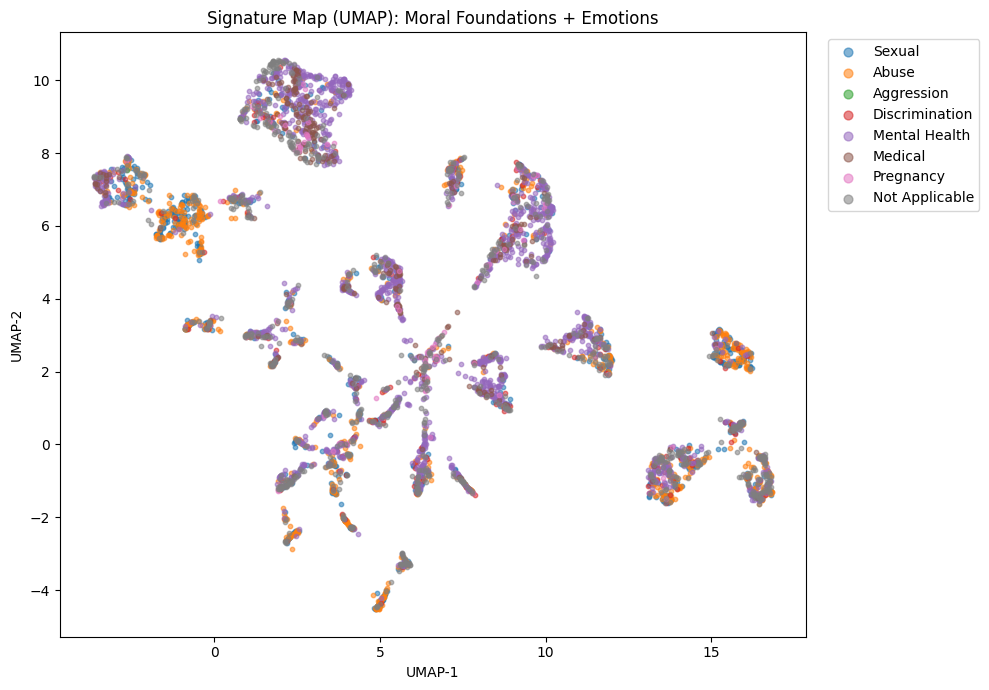

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap

damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
damf_pcols = [f"damf_{x}_p" for x in damf_labels]
emo_cols_5 = ["emo_fear_p","emo_anger_p","emo_enjoyment_p","emo_sadness_p","emo_disgust_contempt_p"]

feat_cols = damf_pcols + emo_cols_5
X = df[feat_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean(numeric_only=True))

Xz = StandardScaler().fit_transform(X)

Z = umap.UMAP(n_neighbors=35, min_dist=0.12, metric="euclidean", random_state=42).fit_transform(Xz)

# color by primary TW label (priority)
TW_LABELS = ["Medical","Mental Health","Abuse","Aggression","Sexual","Discrimination","Pregnancy","Not Applicable"]
priority = ["Sexual","Abuse","Aggression","Discrimination","Mental Health","Medical","Pregnancy","Not Applicable"]

def pick_primary(row):
    for lab in priority:
        if lab in df.columns and row.get(lab, 0) == 1:
            return lab
    return "Unlabeled"

df["primary_label"] = df.apply(pick_primary, axis=1)

plt.figure(figsize=(10,7))
for lab in priority:
    mask = (df["primary_label"] == lab)
    plt.scatter(Z[mask,0], Z[mask,1], s=10, alpha=0.55, label=lab)

plt.title("Signature Map (UMAP): Moral Foundations + Emotions")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [5]:
Z = umap.UMAP(
    n_neighbors=75,
    min_dist=0.25,
    metric="cosine",
    random_state=42
).fit_transform(Xz)


/home/ubuntu/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


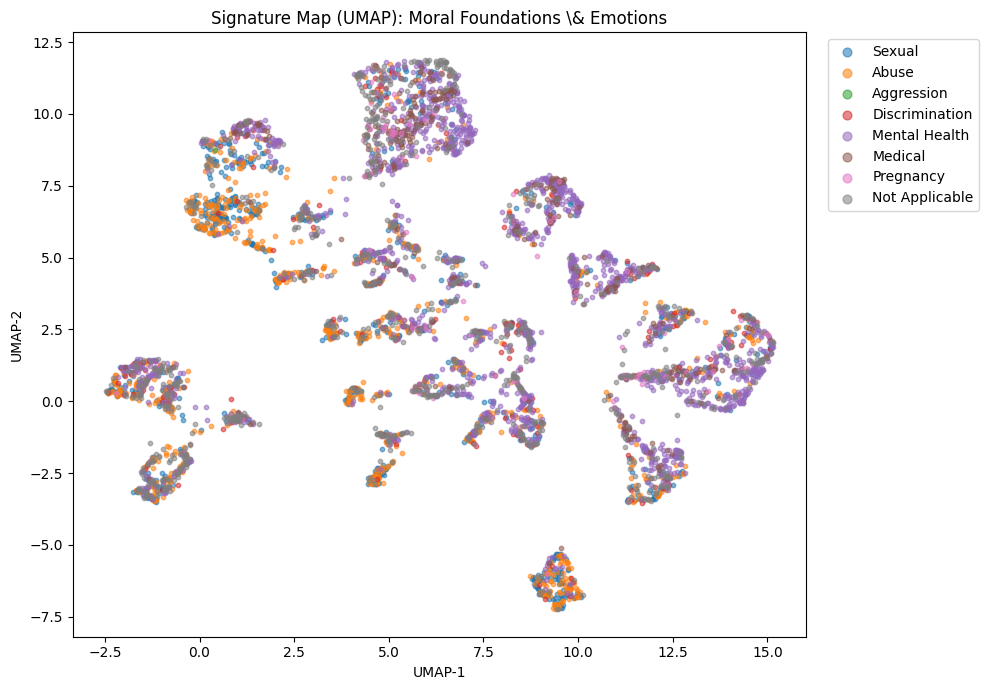

In [6]:
import matplotlib.pyplot as plt

priority = ["Sexual","Abuse","Aggression","Discrimination","Mental Health","Medical","Pregnancy","Not Applicable"]

def pick_primary(row):
    for lab in priority:
        if lab in df.columns and row.get(lab, 0) == 1:
            return lab
    return "Unlabeled"

df["primary_label"] = df.apply(pick_primary, axis=1)

plt.figure(figsize=(10, 7))
for lab in priority:
    mask = (df["primary_label"] == lab)
    plt.scatter(Z[mask,0], Z[mask,1], s=10, alpha=0.55, label=lab)

plt.title("Signature Map (UMAP): Moral Foundations \\& Emotions")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


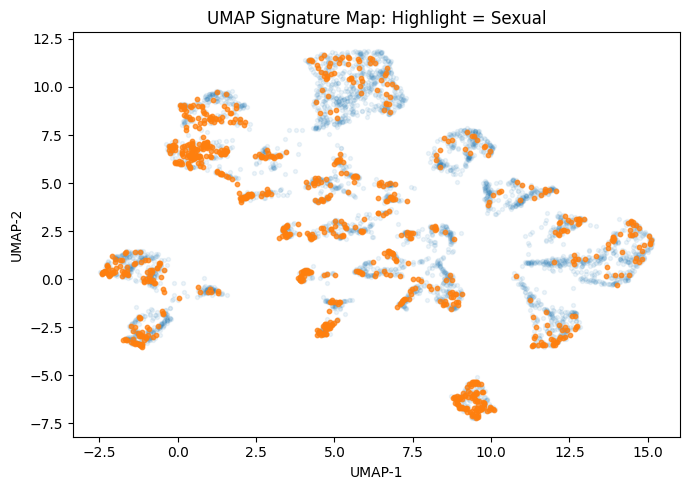

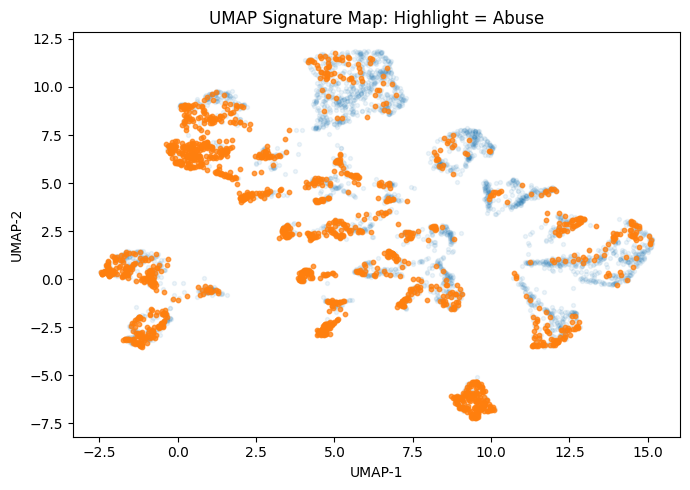

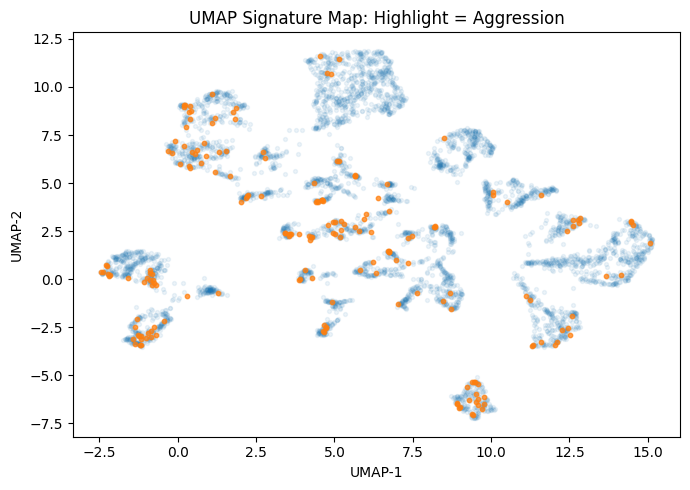

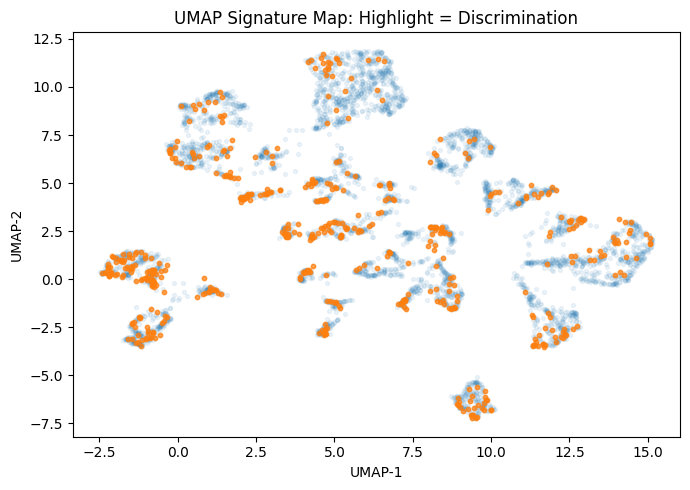

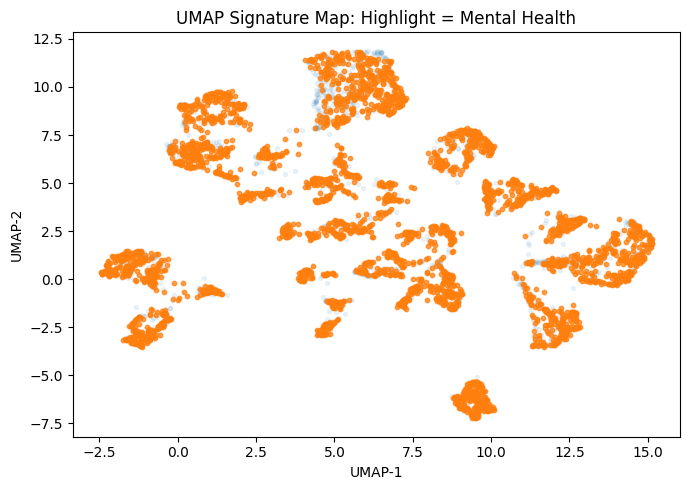

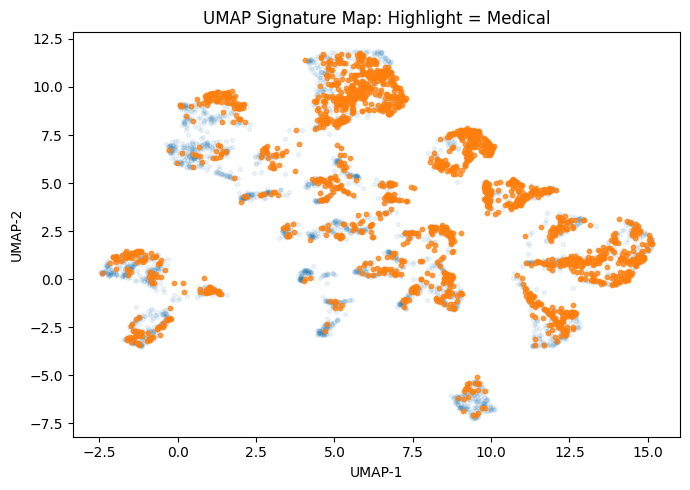

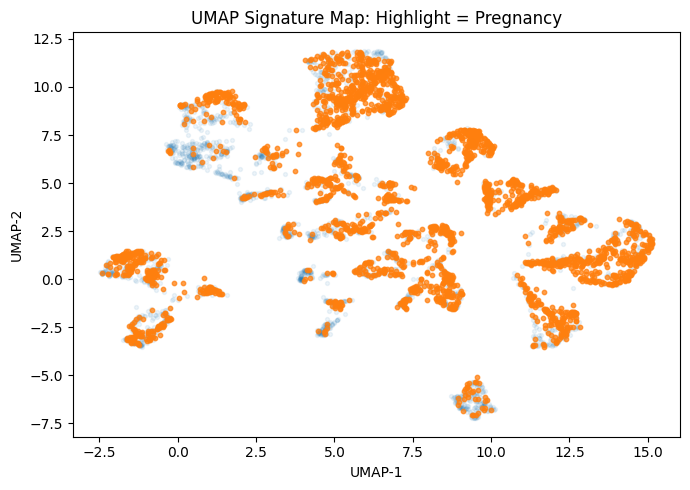

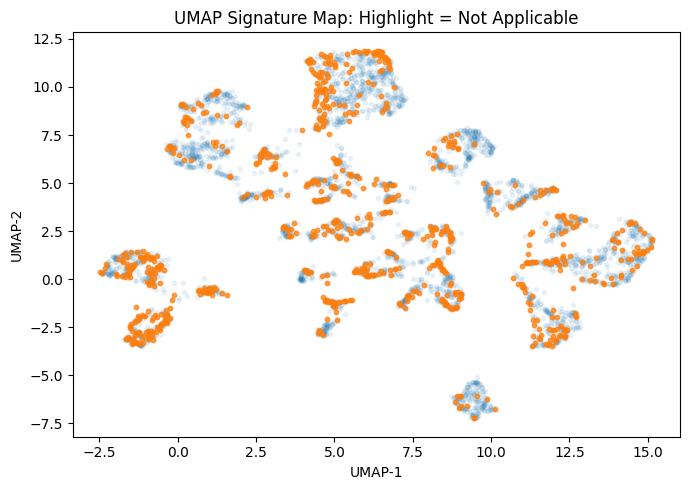

In [7]:
import matplotlib.pyplot as plt

coords_x, coords_y = Z[:,0], Z[:,1]
labels = ["Sexual","Abuse","Aggression","Discrimination","Mental Health","Medical","Pregnancy","Not Applicable"]

for lab in labels:
    plt.figure(figsize=(7,5))
    mask = (df[lab] == 1)

    plt.scatter(coords_x[~mask], coords_y[~mask], s=8, alpha=0.08)
    plt.scatter(coords_x[mask],  coords_y[mask],  s=10, alpha=0.75)

    plt.title(f"UMAP Signature Map: Highlight = {lab}")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

k = 12
df["umap_cluster"] = KMeans(n_clusters=k, random_state=42).fit_predict(Z)

damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
damf_pcols = [f"damf_{x}_p" for x in damf_labels]
emo_cols_5 = ["emo_fear_p","emo_anger_p","emo_enjoyment_p","emo_sadness_p","emo_disgust_contempt_p"]

sig = df.groupby("umap_cluster")[damf_pcols + emo_cols_5].mean(numeric_only=True)

def top_feats(row, top=3):
    return ", ".join(row.sort_values(ascending=False).head(top).index.str.replace("damf_","").str.replace("emo_","").str.replace("_p",""))

summary = pd.DataFrame({
    "top_moral": sig[damf_pcols].apply(top_feats, axis=1),
    "top_emo":   sig[emo_cols_5].apply(top_feats, axis=1),
    "n": df["umap_cluster"].value_counts().sort_index()
}).sort_index()

summary


,top_moral,top_emo,n
umap_cluster,,,
0,"purity, harm, degradation","sadness, anger, disgust_contempt",278
1,"loyalty, degradation, harm","anger, disgust_contempt, sadness",238
2,"care, harm, degradation","sadness, anger, disgust_contempt",696
3,"harm, degradation, purity","sadness, anger, disgust_contempt",243
4,"harm, care, degradation","anger, disgust_contempt, sadness",269
5,"fairness, care, harm","anger, disgust_contempt, sadness",348
6,"authority, care, loyalty","anger, disgust_contempt, sadness",562
7,"degradation, harm, authority","sadness, disgust_contempt, anger",706
8,"loyalty, care, harm","sadness, anger, disgust_contempt",530


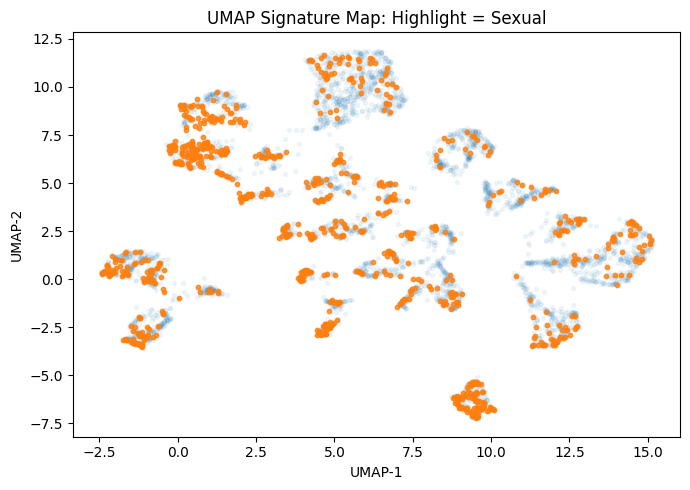

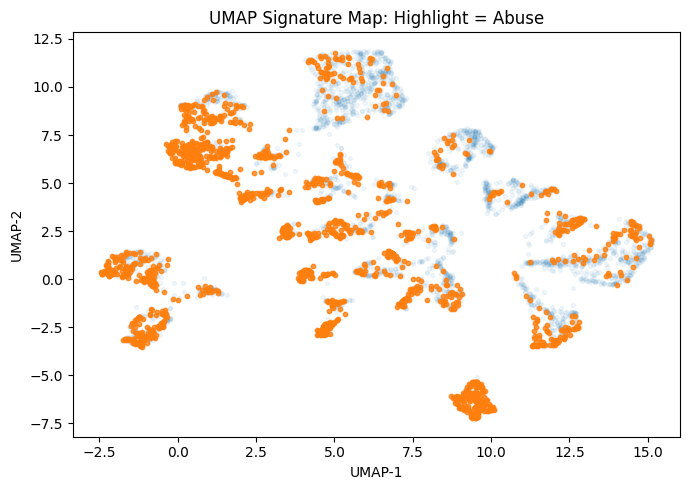

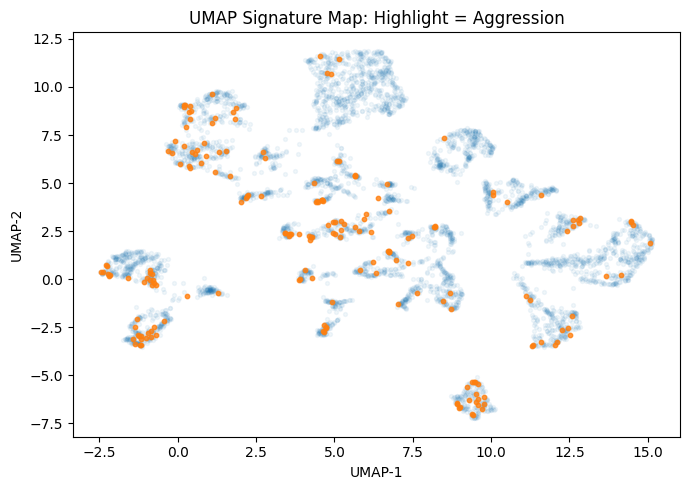

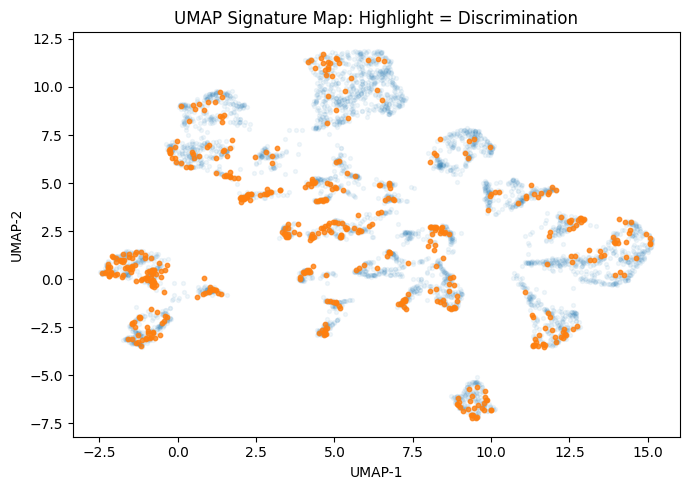

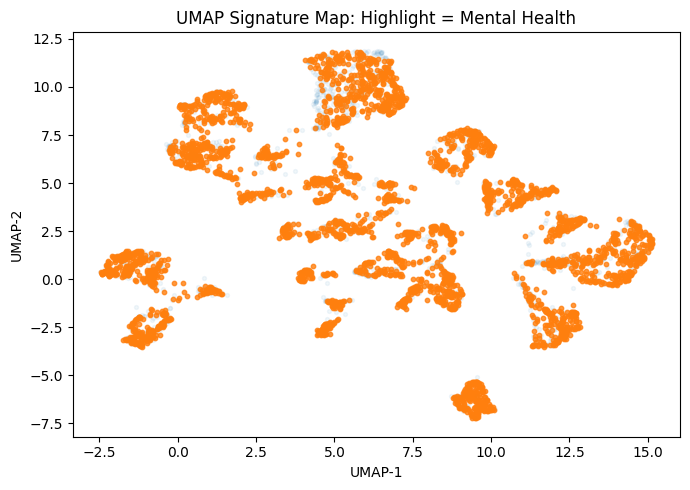

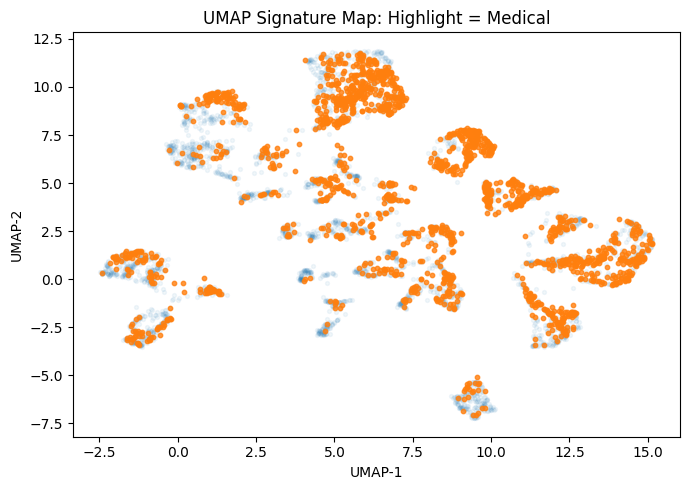

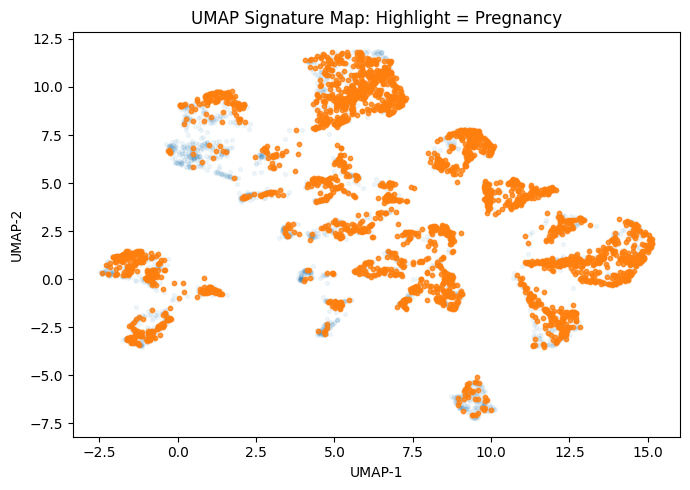

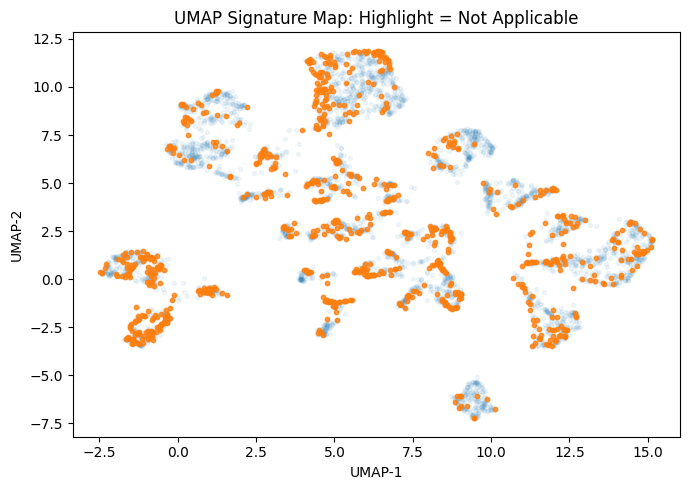

In [9]:
import matplotlib.pyplot as plt

labels = ["Sexual","Abuse","Aggression","Discrimination","Mental Health","Medical","Pregnancy","Not Applicable"]
x, y = Z[:,0], Z[:,1]

for lab in labels:
    plt.figure(figsize=(7,5))
    m = (df[lab] == 1)

    plt.scatter(x[~m], y[~m], s=8, alpha=0.06)   # background
    plt.scatter(x[m],  y[m],  s=10, alpha=0.80)  # highlighted

    plt.title(f"UMAP Signature Map: Highlight = {lab}")
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
    plt.tight_layout()
    plt.show()


In [12]:
from sklearn.cluster import KMeans
import pandas as pd

k = 12
df["umap_cluster"] = KMeans(n_clusters=k, random_state=42).fit_predict(Z)

damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
damf_pcols = [f"damf_{x}_p" for x in damf_labels]
emo_cols_5 = ["emo_fear_p","emo_anger_p","emo_enjoyment_p","emo_sadness_p","emo_disgust_contempt_p"]

sig = df.groupby("umap_cluster")[damf_pcols + emo_cols_5].mean(numeric_only=True)

def top_feats(row, top=3):
    return ", ".join(row.sort_values(ascending=False).head(top).index.str.replace("damf_","").str.replace("emo_","").str.replace("_p",""))

summary = pd.DataFrame({
    "top_moral": sig[damf_pcols].apply(top_feats, axis=1),
    "top_emo":   sig[emo_cols_5].apply(top_feats, axis=1),
    "n": df["umap_cluster"].value_counts().sort_index()
}).sort_index()

summary


,top_moral,top_emo,n
umap_cluster,,,
0,"purity, harm, degradation","sadness, anger, disgust_contempt",278
1,"loyalty, degradation, harm","anger, disgust_contempt, sadness",238
2,"care, harm, degradation","sadness, anger, disgust_contempt",696
3,"harm, degradation, purity","sadness, anger, disgust_contempt",243
4,"harm, care, degradation","anger, disgust_contempt, sadness",269
5,"fairness, care, harm","anger, disgust_contempt, sadness",348
6,"authority, care, loyalty","anger, disgust_contempt, sadness",562
7,"degradation, harm, authority","sadness, disgust_contempt, anger",706
8,"loyalty, care, harm","sadness, anger, disgust_contempt",530


In [10]:
import pandas as pd

TW_LABELS = ["Sexual","Abuse","Aggression","Discrimination","Mental Health","Medical","Pregnancy","Not Applicable"]

cluster_size = df.groupby("umap_cluster").size()

# cluster-wise label prevalence (% within cluster)
cluster_label_rate = df.groupby("umap_cluster")[TW_LABELS].mean()  # 0-1
overall_rate = df[TW_LABELS].mean()  # baseline

# enrichment = cluster rate - overall rate
enrich = cluster_label_rate.subtract(overall_rate, axis=1)

# show top 2 enriched labels per cluster
def top2(row):
    s = row.sort_values(ascending=False).head(2)
    return ", ".join([f"{i} (+{v:.2f})" for i, v in s.items()])

enrich_summary = pd.DataFrame({
    "n": cluster_size,
    "top_enriched_labels": enrich.apply(top2, axis=1),
})

enrich_summary.sort_index()


,n,top_enriched_labels
umap_cluster,,
0,278,"Medical (+0.40), Pregnancy (+0.30)"
1,238,"Abuse (+0.34), Sexual (+0.15)"
2,696,"Pregnancy (+0.17), Medical (+0.11)"
3,243,"Abuse (+0.07), Sexual (+0.06)"
4,269,"Abuse (+0.44), Sexual (+0.25)"
5,348,"Discrimination (+0.11), Abuse (+0.09)"
6,562,"Abuse (+0.07), Discrimination (+0.05)"
7,706,"Medical (+0.18), Pregnancy (+0.18)"
8,530,"Pregnancy (+0.05), Not Applicable (+0.05)"
